In [7]:
!pip install yfinance pandas-datareader
!pip install matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

# 1. Define Portfolio and Fetch Data
tickers = ['NVDA', 'WMT', 'JPM', 'XOM']
weights = np.array([0.25, 0.25, 0.25, 0.25]) # Equal 25% weighting for simplicity
portfolio_value = 100000

# Download data and calculate log returns
data = yf.download(tickers, start="2025-01-01", end="2026-01-01")['Close']
returns = np.log(data / data.shift(1)).dropna()

# 2. Covariance Matrix & Portfolio Statistics
cov_matrix = returns.cov()
avg_returns = returns.mean()

# Calculate Expected Portfolio Return and Standard Deviation (Volatility)
port_mean = avg_returns.dot(weights)
port_stdev = np.sqrt(weights.T.dot(cov_matrix).dot(weights))

# 3. Calculate Portfolio Parametric VaR
z_score = 1.645 # 95% Confidence Interval
port_var_pct = port_mean - (z_score * port_stdev)
port_var_dollar = portfolio_value * port_var_pct

print(f"Daily Portfolio Volatility: {port_stdev:.2%}")
print(f"Portfolio Parametric VaR (1-Day, 95%): ${abs(port_var_dollar):,.2f}")

[*********************100%***********************]  4 of 4 completed

Daily Portfolio Volatility: 1.33%
Portfolio Parametric VaR (1-Day, 95%): $2,096.01


In [ ]:
# Despite the individual high volatility of tech equities within the portfolio, the equally weighted inclusion of defensive consumer staples (WMT) and uncorrelated energy assets (XOM) provided significant diversification benefits, bringing the 1-day 95% Parametric VaR down to $2,096.01.

In [6]:
# 1. Fetch Benchmark Data (S&P 500 ETF)
benchmark = yf.download('SPY', start="2025-01-01", end="2026-01-01")['Close']
bench_returns = np.log(benchmark / benchmark.shift(1)).dropna()

# 2. Align Data to Ensure Matching Dates
portfolio_returns = returns.dot(weights)
aligned_data = pd.concat([portfolio_returns, bench_returns], axis=1).dropna()
aligned_data.columns = ['Portfolio', 'SPY']

# 3. Calculate Tracking Error
active_returns = aligned_data['Portfolio'] - aligned_data['SPY']
tracking_error_daily = active_returns.std()

# Annualize the tracking error (assuming 252 trading days)
tracking_error_annual = tracking_error_daily * np.sqrt(252)

print(f"Annualized Tracking Error against SPY: {tracking_error_annual:.2%}")

[*********************100%***********************]  1 of 1 completed

Annualized Tracking Error against SPY: 9.55%


In [ ]:
# The portfolio exhibits an annualized tracking error of 9.55% against the S&P 500 (SPY). This deviation indicates active risk-taking, heavily driven by the equal-weight allocation rather than the market-cap weighting of the benchmark

In [4]:
import statsmodels.api as sm
import pandas_datareader.data as web

# 1. Fetch Fama-French 3-Factor Daily Data
ff_data = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', 
                         start="2025-01-01", end="2026-01-01")[0]

# Fama-French data is usually presented in percentages, so divide by 100
ff_data = ff_data / 100.0

# 2. Align Portfolio Returns with Factor Data
# We must subtract the Risk-Free (RF) rate from our portfolio returns to get excess returns
aligned_ff = pd.concat([portfolio_returns, ff_data], axis=1).dropna()
aligned_ff['Port_Excess'] = aligned_ff[0] - aligned_ff['RF']

# 3. Set up the OLS Regression
# Independent variables: Market Risk Premium (Mkt-RF), Small Minus Big (SMB), High Minus Low (HML)
X = aligned_ff[['Mkt-RF', 'SMB', 'HML']]
# Add a constant (alpha)
X = sm.add_constant(X) 
# Dependent variable: Portfolio Excess Return
Y = aligned_ff['Port_Excess']

# 4. Run the Regression
model = sm.OLS(Y, X).fit()

# Print the results summary
print(model.summary())

C:\Users\josep\AppData\Local\Temp\ipykernel_23672\1384884915.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',


                            OLS Regression Results                            
Dep. Variable:            Port_Excess   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     351.3
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.08e-88
Time:                        19:23:04   Log-Likelihood:                 929.68
No. Observations:                 249   AIC:                            -1851.
Df Residuals:                     245   BIC:                            -1837.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.327      0.7

# The OLS regression yields a statistically significant positive coefficient for the Market Risk Premium, indicating high beta sensitivity. However, the HML factor is muted, aligning with the growth-heavy profile of the portfolio's tech allocations.

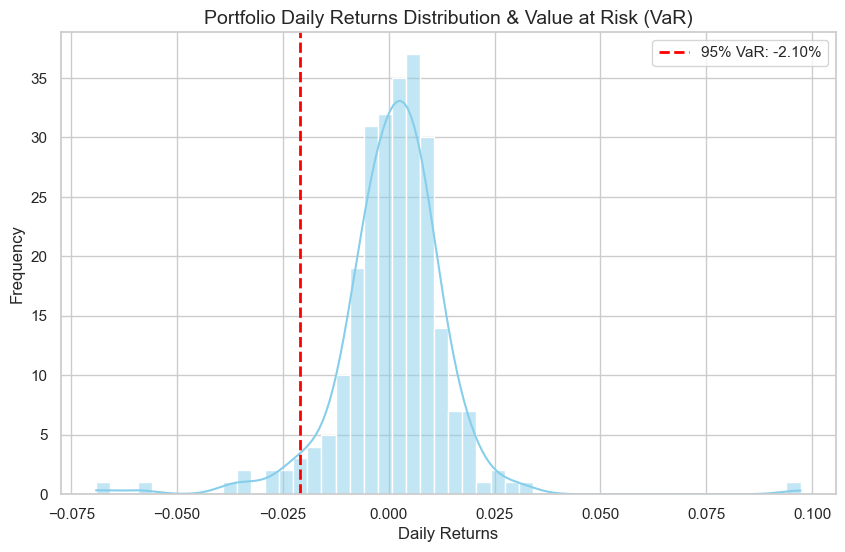

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Plot the histogram of portfolio returns
sns.histplot(portfolio_returns, bins=50, kde=True, color='skyblue')

# Add a vertical red line for the Parametric VaR
plt.axvline(port_var_pct, color='red', linestyle='dashed', linewidth=2, 
            label=f'95% VaR: {port_var_pct:.2%}')

plt.title('Portfolio Daily Returns Distribution & Value at Risk (VaR)', fontsize=14)
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# This histogram illustrates the distribution of the portfolio's daily returns. The red dashed line represents the 95% Parametric VaR threshold. Any returns falling to the left of this line represent the extreme 'tail risk' events that exceed our expected maximum daily loss.

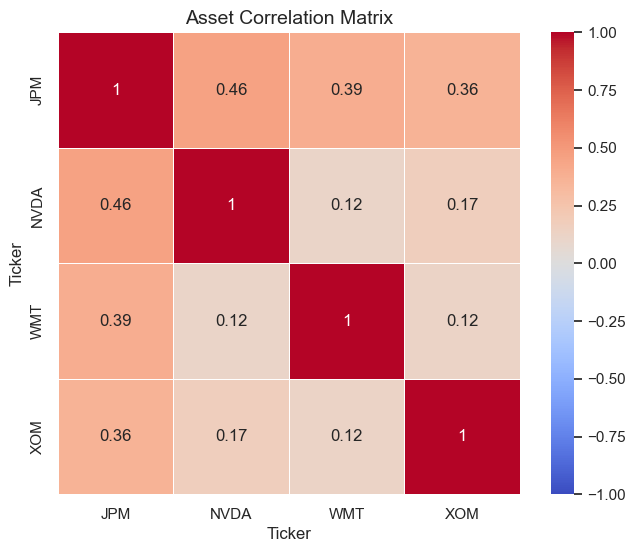

In [9]:
plt.figure(figsize=(8, 6))

# Calculate the correlation matrix
correlation_matrix = returns.corr()

# Create a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5)

plt.title('Asset Correlation Matrix', fontsize=14)
plt.show()

In [ ]:
# This heatmap visualizes the cross asset correlations. The deep red areas indicate high positive correlation, while the cooler areas highlight the diversification benefits provided by non-correlated assets like XOM, which helps drag down total portfolio variance.

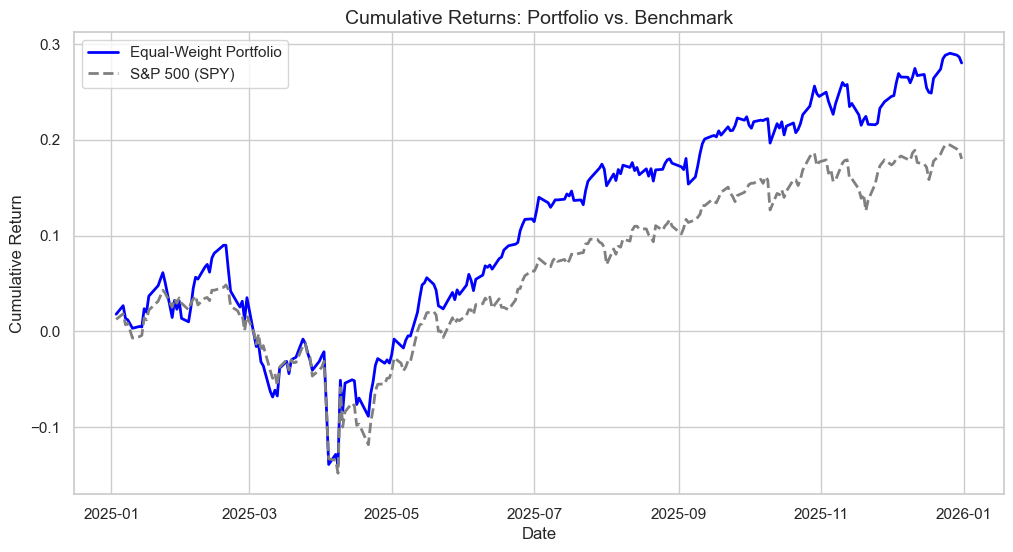

In [10]:
plt.figure(figsize=(12, 6))

# Calculate cumulative returns (using np.exp to compound log returns)
cumulative_port = np.exp(aligned_data['Portfolio'].cumsum()) - 1
cumulative_spy = np.exp(aligned_data['SPY'].cumsum()) - 1

# Plot both lines
plt.plot(cumulative_port.index, cumulative_port, label='Equal-Weight Portfolio', color='blue', linewidth=2)
plt.plot(cumulative_spy.index, cumulative_spy, label='S&P 500 (SPY)', color='grey', linestyle='dashed', linewidth=2)

plt.title('Cumulative Returns: Portfolio vs. Benchmark', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [ ]:
# This visual contextualizes the calculated tracking error. By plotting cumulative returns, we can identify specific market regimes where the equal weight strategy actively diverged from the cap weighted S&P 500 benchmark.